In [3]:
import pandas as pd

df = pd.read_csv("/Users/julia/Documents/spotify_millsongdata.csv")

if "text" in df.columns:
    # Sprawdź, ile utworów ma brakujące teksty
    missing_lyrics = df["text"].isna().sum()
    total_songs = len(df)

    print(f"Liczba utworów w datasetcie: {total_songs}")
    print(f"Liczba utworów bez tekstu: {missing_lyrics}")
    print(f"Procent utworów bez tekstu: {missing_lyrics / total_songs * 100:.2f}%")
else:
    print("Brak kolumny 'text' – dataset nie zawiera tekstów piosenek.")

Liczba utworów w datasetcie: 57650
Liczba utworów bez tekstu: 0
Procent utworów bez tekstu: 0.00%


In [4]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('averaged_perceptron_tagger')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Funkcja do mapowania POS na format WordNet
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()  # Pobranie pierwszej litery tagu POS
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)  # Jeśli brak w słowniku, przyjmujemy rzeczownik

def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Usunięcie liczb
    text = re.sub(r'\W+', ' ', text)  # Usunięcie znaków specjalnych
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]  # Usunięcie stop words
    words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]  # Poprawna lematyzacja
    return ' '.join(words)

df['processed_text'] = df['text'].apply(preprocess_text)


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/julia/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['processed_text'])

# Sprawdzenie wymiarów macierzy
print(X.shape)  # (liczba_piosenek, liczba_słów)


(57650, 5000)


In [6]:
from sklearn.decomposition import LatentDirichletAllocation

# Ustawienie liczby tematów
num_topics = 8

lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X)

# Pobranie słów kluczowych dla każdego tematu
def display_topics(model, feature_names, num_words):
    for topic_idx, topic in enumerate(model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
        print(f"Temat {topic_idx+1}: {', '.join(words)}")


# Wyświetlenie tematów
display_topics(lda, vectorizer.get_feature_names_out(), 10)


Temat 1: come, rock, home, roll, good, little, old, new, town, man
Temat 2: oh, love, know, say, time, want, need, way, make, feel
Temat 3: love, like, come, feel, dance, tonight, night, blue, make, light
Temat 4: life, let, world, heart, day, god, dream, love, come, know
Temat 5: na, gon, baby, know, wan, want, let, make, cause, ta
Temat 6: la, away, come, time, like, eye, know, turn, fall, life
Temat 7: like, yeah, ya, nigga, fuck, know, em, shit, cause, money
Temat 8: like, girl, say, hey, man, boy, little, look, make, big


In [7]:
!pip install transformers
!pip install torch

In [8]:
from transformers import pipeline

# 1. Pipeline do klasyfikacji Zero-Shot
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# 2. Kandydaci na etykiety tematów
candidate_labels = [
    "love", "heartbreak", "party", "freedom", "sadness",
    "happiness", "rebellion", "nostalgia", "hope", "anger"
]

# 3. Funkcja przypisująca etykiety
def get_topic_labels(lda_model, feature_names, num_words=10):
    topic_labels = []

    for topic_idx, topic in enumerate(lda_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
        topic_keywords = " ".join(words)

        result = classifier(topic_keywords, candidate_labels)
        label = result["labels"][0]  # Najbardziej prawdopodobna etykieta
        topic_labels.append((f"Topic {topic_idx+1}", label, words))

    return topic_labels

# 4. Wywołanie
labels = get_topic_labels(lda, vectorizer.get_feature_names_out())

# 5. Wyświetlenie
for topic_name, label, words in labels:
    print(f"{topic_name} -> {label.upper()} | Keywords: {', '.join(words)}")


Device set to use cpu


Topic 1 -> NOSTALGIA | Keywords: come, rock, home, roll, good, little, old, new, town, man
Topic 2 -> LOVE | Keywords: oh, love, know, say, time, want, need, way, make, feel
Topic 3 -> LOVE | Keywords: love, like, come, feel, dance, tonight, night, blue, make, light
Topic 4 -> HOPE | Keywords: life, let, world, heart, day, god, dream, love, come, know
Topic 5 -> HOPE | Keywords: na, gon, baby, know, wan, want, let, make, cause, ta
Topic 6 -> HEARTBREAK | Keywords: la, away, come, time, like, eye, know, turn, fall, life
Topic 7 -> ANGER | Keywords: like, yeah, ya, nigga, fuck, know, em, shit, cause, money
Topic 8 -> HOPE | Keywords: like, girl, say, hey, man, boy, little, look, make, big


In [19]:
from transformers import pipeline
import torch

# Sprawdzenie, czy dostępny GPU
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'cuda' if device == 0 else 'cpu'}")

# Ładujemy pipeline do analizy sentymentu
sentiment_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=device)

def classify_sentiment(text):
    if not text or text.strip() == "":
        return "neutral"  # domyślna wartość, jeśli tekst jest pusty
    try:
        result = sentiment_pipeline(text[:512])[0]  # ograniczenie do 512 tokenów
        label = result['label']
        # Mapowanie na uproszczone etykiety
        if '1' in label or '2' in label:
            return 'negative'
        elif '3' in label:
            return 'neutral'
        else:
            return 'positive'
    except Exception as e:
        print(f"Błąd dla tekstu: {text[:30]}... – {e}")
        return 'neutral'
df['sentiment'] = df['processed_text'].apply(classify_sentiment)
df[['processed_text', 'sentiment']].head()


Device: cpu


Device set to use cpu


,processed_text,sentiment
0,look face wonderful face mean something specia...,positive
1,take easy please touch gently like summer even...,positive
2,never know go put lousy rotten show boy tough ...,negative
3,make somebody happy question give take learn s...,negative
4,make somebody happy question give take learn s...,negative


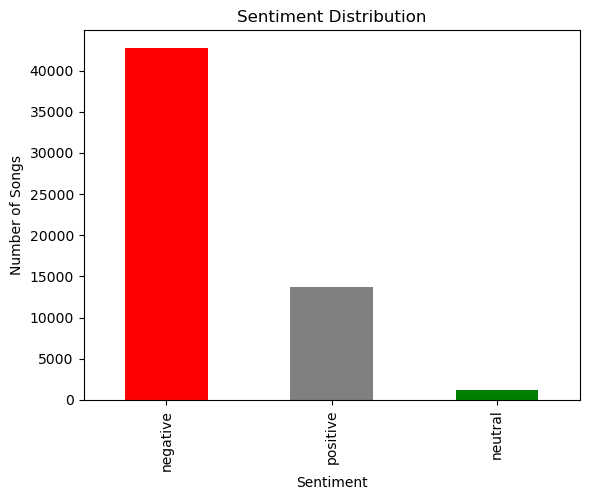

In [20]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution', color=['red', 'gray', 'green'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Songs')
plt.show()


In [25]:
!pip install transformers sentencepiece

  Using cached sentencepiece-0.2.0-cp312-cp312-macosx_10_9_x86_64.whl.metadata (7.7 kB)
Using cached sentencepiece-0.2.0-cp312-cp312-macosx_10_9_x86_64.whl (1.2 MB)


In [31]:
import random
from transformers import pipeline

summarizer = pipeline("summarization", model="knkarthick/MEETING_SUMMARY")

# Wybierz losowy wiersz, który ma tekst po przetwarzaniu
random_row = df.dropna(subset=['processed_text']).sample(1).iloc[0]
original_text = random_row['text']

# Streszczanie
summary = summarizer(original_text, max_length=100, min_length=30, do_sample=False)[0]['summary_text']

print("🎵 Oryginalny tekst (fragment):")
print(original_text[:500])  # tylko fragment, żeby nie przytłaczało

print("\n📝 Streszczenie:")
print(summary)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/337 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


🎵 Oryginalny tekst (fragment):
They used to call him Jesus  
Long time ago  
They're still calling him Jesus  
Don't you know  
They crossed the wood and hanged him  
A long time ago  
They still misunderstand him  
Those who don't know  
And in the evening his love will lead the blind  
In every secret corner there in your mind  
  
They called him Gautama Buddha  
Oh long time ago  
He turned the world to order  
Don't you know  
He used to sit knowing  
Oh long time ago  
Where you and me were going  
And

📝 Streszczenie:
They used to call him Jesus, now they call him Gautama Buddha. In the evening his love will lead the blind.


In [32]:
from transformers import pipeline

summarizer = pipeline("text-generation", model="Open-Orca/Mistral-7B-OpenOrca")

prompt = f"Summarize the following song lyrics in one or two sentences:\n\n{original_text}"

output = summarizer(prompt, max_length=100, do_sample=True)[0]["generated_text"]
print(output)


config.json:   0%|          | 0.00/623 [00:00<?, ?B/s]

pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:799: UserWarning: Not enough free disk space to download the file. The expected file size is: 9943.04 MB. The target location /Users/julia/.cache/huggingface/hub/models--Open-Orca--Mistral-7B-OpenOrca/blobs only has 5044.49 MB free disk space.
  warnings.warn(


pytorch_model-00001-of-00002.bin:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:799: UserWarning: Not enough free disk space to download the file. The expected file size is: 4540.55 MB. The target location /Users/julia/.cache/huggingface/hub/models--Open-Orca--Mistral-7B-OpenOrca/blobs only has 143.71 MB free disk space.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:799: UserWarning: Not enough free disk space to download the file. The expected file size is: 9943.04 MB. The target location /Users/julia/.cache/huggingface/hub/models--Open-Orca--Mistral-7B-OpenOrca/blobs only has 143.71 MB free disk space.
  warnings.warn(


pytorch_model-00002-of-00002.bin:  37%|###6      | 2.63G/7.17G [00:00<?, ?B/s]

pytorch_model-00001-of-00002.bin:  18%|#8        | 2.25G/12.2G [00:00<?, ?B/s]

ValueError: Could not load model Open-Orca/Mistral-7B-OpenOrca with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForCausalLM'>, <class 'transformers.models.mistral.modeling_mistral.MistralForCausalLM'>). See the original errors:

while loading with AutoModelForCausalLM, an error is thrown:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/transformers/pipelines/base.py", line 292, in infer_framework_load_model
    model = model_class.from_pretrained(model, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/transformers/models/auto/auto_factory.py", line 600, in from_pretrained
    return model_class.from_pretrained(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/transformers/modeling_utils.py", line 311, in _wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/ana